<a href="https://colab.research.google.com/github/jskimn/aiservice_lesson2/blob/main/NNBasic/006_minist_pytorch/minist_twolayer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PyTorch를 이용한 MNIST TwoLayerNet**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Device 설정

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


전처리

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),           # PyTorch 텐서 변환
    transforms.Normalize((0.5,), (0.5,))  # 정규화 (-1 ~ 1)
])

MNIST 데이터셋 로드

In [8]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.46MB/s]


신경망 모델 클래스 정의

In [9]:
class TwoLayerNet(nn.Module):
    def __init__(self):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 50, bias=False)   # 편향 제거 (Hebbian 방식)
        self.fc2 = nn.Linear(50, 10, bias=False)     # 은닉층 → 출력층 (10 뉴런)

    def forward(self, x):
        x = x.view(-1, 28*28)  # 2D 이미지 -> 1D 벡터 변환
        x = torch.relu(self.fc1(x))  # 은닉층
        x = self.fc2(x)  # Softmax는 CrossEntropyLoss에서 자동 적용됨
        return x

모델, 손실함수, 최적화 함수 생성

In [17]:
model = TwoLayerNet().to(device)
criterion = nn.CrossEntropyLoss() #손실함수: 교차 엔트로피 함수
learning_rate = 0.01  # 학습률

학습

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# 1. 모델 학습
num_epochs = 16
train_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    running_loss = 0.0

    # 모델 학습
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 순전파
        images = images.view(images.size(0), -1)  # [batch_size, 28*28]
        labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=10).float()  # (batch_size, 10)

        # 1. fc1 (입력 → 숨은층) 가중치 업데이트
        hidden_output = torch.relu(model.fc1(images))  # Hidden Layer Output (batch_size, 50)
        for name, param in model.named_parameters():
            if name == "fc1.weight":  # Hidden Layer 가중치 업데이트
                param.data = param.data + learning_rate * torch.matmul(hidden_output.T, images)  # (50, 784)

        # 2. fc2 (숨은층 → 출력) 가중치 업데이트
        for name, param in model.named_parameters():
            if name == "fc2.weight":  # Output Layer 가중치 업데이트
                param.data = param.data + learning_rate * torch.matmul(labels_one_hot.T, hidden_output)  # (10, 50)


    # 훈련 손실 기록
    train_losses.append(running_loss / len(train_loader))

    # 테스트 정확도 계산
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Test Accuracy: {test_acc:.4f}")


Epoch [1/16], Test Accuracy: 0.0980
Epoch [2/16], Test Accuracy: 0.0980
Epoch [3/16], Test Accuracy: 0.0980
Epoch [4/16], Test Accuracy: 0.0980
Epoch [5/16], Test Accuracy: 0.0980


Loss 그래프 시각화

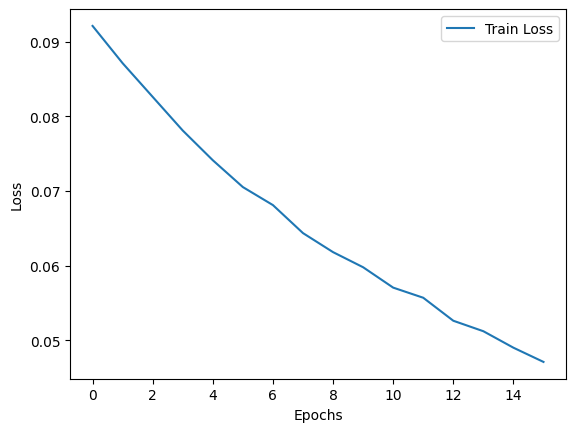

In [26]:
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

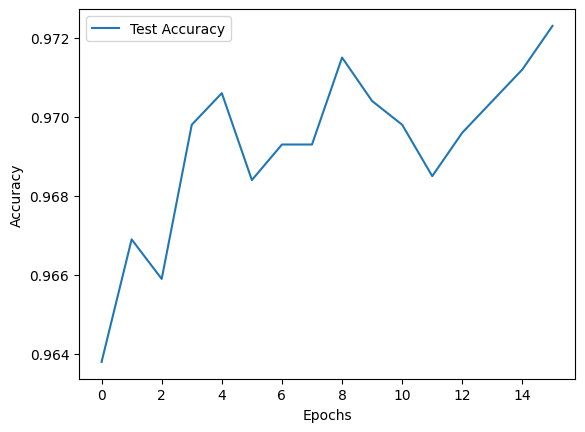

In [27]:
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()